# <h1 style="text-align: center;">2. DESCRIPTIVE</h1>

## 1. How severe is heart failure at admission across genders, based on heart_failure_severity and heart_damage_level?

### Reasoning:
Heart failure severity is recorded on two scales:

- **heart_failure_severity** (levels 2–4): how much heart failure limits daily activity. Level 2 = mild limitation, level 4 = symptoms even at rest.
- **heart_damage_level** (levels 1–4): physical signs of heart failure on examination. Level 1 = no signs, level 4 = shock (the heart cannot pump enough blood).

Our cohort is 58% female. If one sex arrives sicker, later results by gender must take that into account.

### Metrics used:

Share of each sex (%) at every level of heart_failure_severity and heart_damage_level

Share of each sex in the most severe level of each scale

### Visual:
Each bar is 100% of the patients of one sex on one scale. Colours run from green (mildest) to dark red (most severe), so more red at the right-hand end means that sex arrives sicker.

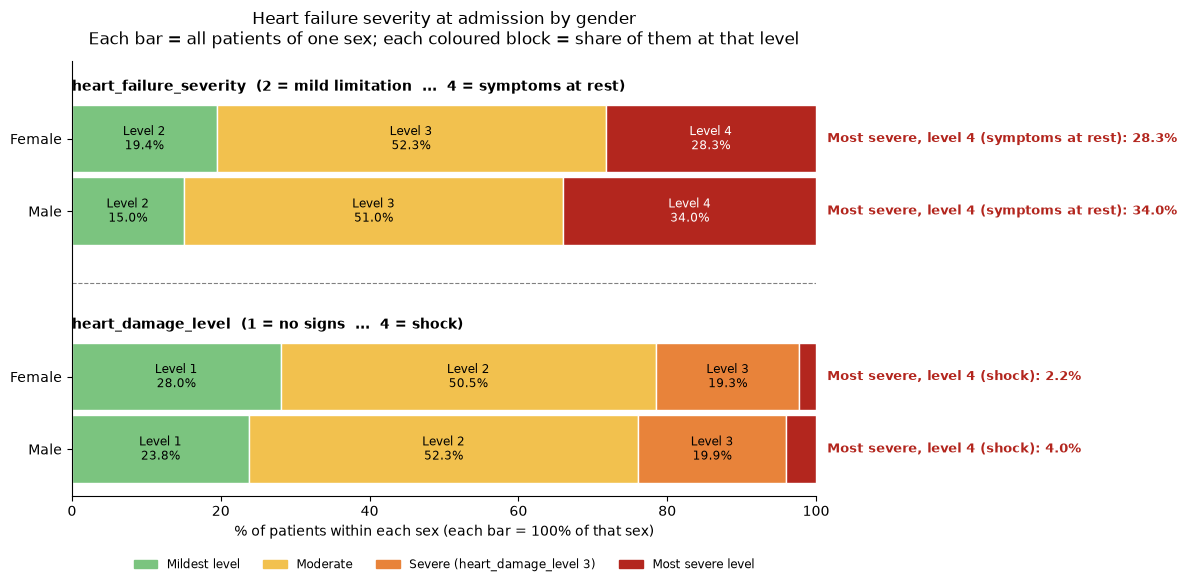

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df_demography = pd.read_csv("Team05_PyCraft_Cleaned_data/demography_cleaned.csv")
df_cardiac_complications = pd.read_csv("Team05_PyCraft_Cleaned_data/cardiac_cleaned.csv")

severity = df_demography[['patient_id', 'gender']].merge(
    df_cardiac_complications[['patient_id', 'heart_failure_severity', 'heart_damage_level']],
    on='patient_id', how='inner'
)

# Share of each sex (%) at every level of each scale
scales = ['heart_failure_severity', 'heart_damage_level']
pct = {s: pd.crosstab(severity['gender'], severity[s], normalize='index') * 100 for s in scales}

colours = {'heart_failure_severity': {2: '#7BC47F', 3: '#F2C14E', 4: '#B3261E'},
           'heart_damage_level': {1: '#7BC47F', 2: '#F2C14E', 3: '#E8833A', 4: '#B3261E'}}
most_severe_text = {'heart_failure_severity': 'level 4 (symptoms at rest)',
                    'heart_damage_level': 'level 4 (shock)'}
bars = [('heart_failure_severity', 'Female', 3.55), ('heart_failure_severity', 'Male', 2.85),
        ('heart_damage_level', 'Female', 1.25), ('heart_damage_level', 'Male', 0.55)]

fig, ax = plt.subplots(figsize=(12, 6))
for scale, sex, y in bars:
    left = 0
    for level, share in pct[scale].loc[sex].items():
        colour = colours[scale][level]
        ax.barh(y, share, left=left, height=0.65, color=colour, edgecolor='white')
        if share >= 6:  # write the level and % inside the segment when it fits
            ax.text(left + share / 2, y, f"Level {level}\n{share:.1f}%", ha='center', va='center',
                    fontsize=8.5, color='white' if colour == '#B3261E' else 'black')
        left += share
    worst = pct[scale].loc[sex].iloc[-1]
    ax.text(101.5, y, f"Most severe, {most_severe_text[scale]}: {worst:.1f}%",
            va='center', fontsize=9, fontweight='bold', color='#B3261E')

ax.text(0, 4.05, "heart_failure_severity  (2 = mild limitation  ...  4 = symptoms at rest)", fontsize=10, fontweight='bold', va='center')
ax.text(0, 1.75, "heart_damage_level  (1 = no signs  ...  4 = shock)", fontsize=10, fontweight='bold', va='center')
ax.axhline(2.15, color='grey', lw=0.8, ls='--')
ax.set_yticks([y for _, _, y in bars])
ax.set_yticklabels([sex for _, sex, _ in bars], fontsize=10)
ax.set_xlim(0, 100)
ax.set_ylim(0.1, 4.3)
ax.set_xlabel("% of patients within each sex (each bar = 100% of that sex)")
ax.set_title("Heart failure severity at admission by gender\n"
             "Each bar = all patients of one sex; each coloured block = share of them at that level",
             fontsize=12, pad=12)
ax.legend(handles=[Patch(color='#7BC47F', label='Mildest level'), Patch(color='#F2C14E', label='Moderate'),
                   Patch(color='#E8833A', label='Severe (heart_damage_level 3)'), Patch(color='#B3261E', label='Most severe level')],
          loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=8.5, frameon=False)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Insights

**Most patients of both sexes arrive with advanced heart failure.** About 81% of women and 85% of men are at heart_failure_severity level 3 or 4. The most common picture for both is heart_failure_severity level 3 with heart_damage_level 2.

**Men arrive slightly sicker on both scales:**
- **heart_failure_severity level 4 (symptoms at rest):** 34.0% of men vs 28.3% of women.
- **heart_damage_level level 4 (shock):** 4.0% of men vs 2.2% of women, almost double.
- **Mildest levels:** women are more often at the mildest level of both scales.

**The gap is small.** Level 3 of heart_damage_level is almost the same for both sexes (about 19–20%), so the extra severity in men is concentrated in shock. Shock is rare (60 patients), so that difference rests on small numbers.

### How it helps:

If men later show worse outcomes, part of the reason may simply be that they arrived sicker.

Supports using heart_failure_severity and heart_damage_level alongside gender in predictive models.

Flags shock (heart_damage_level 4) as the level to watch most closely at triage, especially in men.

## 2. How does the risk of death change over the first 4 weeks, based on the patient's consciousness level at admission?

### Reasoning:
Reduced consciousness in heart failure usually means the brain is not getting enough blood or oxygen, which is a warning sign of death. Following deaths day by day shows how dangerous each consciousness level is and **how early** that danger strikes.

`consciousness` levels, from least to most severe: Clear → ResponsiveToSound → ResponsiveToPain → Nonresponsive.

### Metrics used:

Consciousness level at admission (responsivenes_cleaned.csv)

death_time_days — day of death counted from admission (hospitalization_discharge_cleaned.csv)

Cumulative mortality (% of each group who have died) on every day up to day 28

### Visual:
Each line is one consciousness group and shows the % of that group who have died by each day. The higher and steeper the line, the more dangerous that level. Dots mark the end of each week.

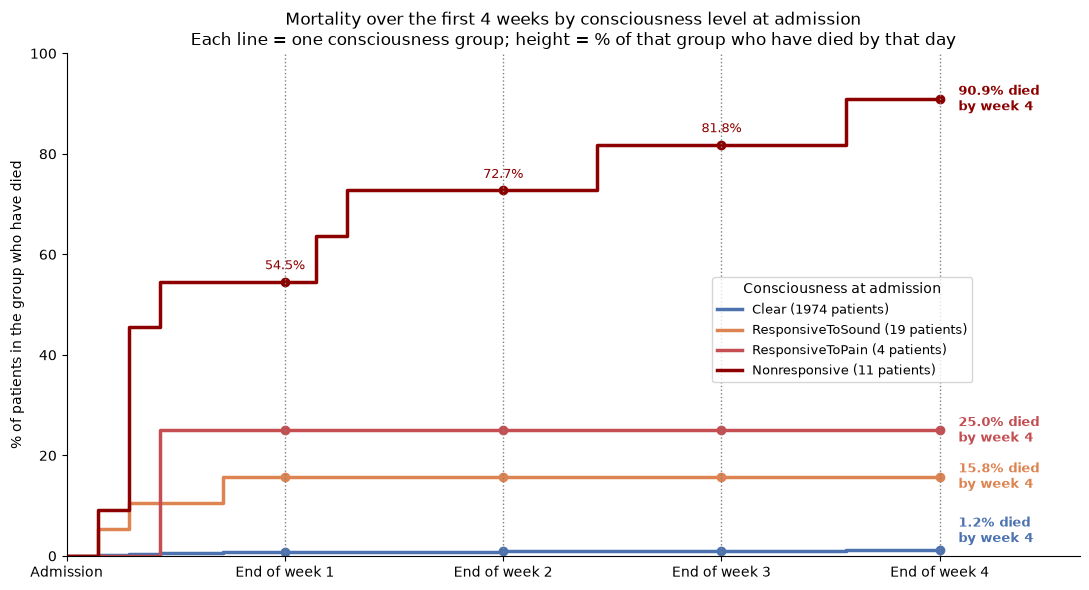

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_responsivenes = pd.read_csv("Team05_PyCraft_Cleaned_data/responsivenes_cleaned.csv")
df_hospitalization = pd.read_csv("Team05_PyCraft_Cleaned_data/hospitalization_discharge_cleaned.csv")

mort = df_responsivenes[['patient_id', 'consciousness']].merge(
    df_hospitalization[['patient_id', 'death_time_days']], on='patient_id', how='inner'
)

consciousness_order = ['Clear', 'ResponsiveToSound', 'ResponsiveToPain', 'Nonresponsive']
colours = {'Clear': '#4C72B0', 'ResponsiveToSound': '#DD8452', 'ResponsiveToPain': '#C44E52', 'Nonresponsive': '#8C0000'}
days = np.arange(0, 29)

fig, ax = plt.subplots(figsize=(11, 6))
for level in consciousness_order:
    group = mort[mort['consciousness'] == level]
    # % of the group who have died by each day (patients with no death have no death_time_days)
    cumulative = [(group['death_time_days'] <= d).mean() * 100 for d in days]
    ax.step(days, cumulative, where='post', color=colours[level], lw=2.5, label=f"{level} ({len(group)} patients)")
    ax.plot([7, 14, 21, 28], [cumulative[d] for d in [7, 14, 21, 28]], 'o', color=colours[level], ms=6)
    ax.text(28.6, max(cumulative[28], 5), f"{cumulative[28]:.1f}% died\nby week 4", va='center', fontsize=9,
            fontweight='bold', color=colours[level])
    if level == 'Nonresponsive':  # show the weekly climb for the most severe group
        for d in [7, 14, 21]:
            ax.annotate(f"{cumulative[d]:.1f}%", (d, cumulative[d]), textcoords='offset points', xytext=(0, 9),
                        ha='center', fontsize=9, color=colours[level])

for d in [7, 14, 21, 28]:
    ax.axvline(d, color='grey', ls=':', lw=1)
ax.set_xticks([0, 7, 14, 21, 28])
ax.set_xticklabels(['Admission', 'End of week 1', 'End of week 2', 'End of week 3', 'End of week 4'])
ax.set_xlim(0, 32.5)
ax.set_ylim(0, 100)
ax.set_ylabel("% of patients in the group who have died")
ax.set_title("Mortality over the first 4 weeks by consciousness level at admission\n"
             "Each line = one consciousness group; height = % of that group who have died by that day",
             fontsize=12)
ax.legend(title="Consciousness at admission", loc='center right', bbox_to_anchor=(0.9, 0.45), fontsize=9)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Insights

**The worse the consciousness, the higher the death rate.** By the end of week 4:
- Clear: 1.2% have died (23 of 1,974)
- ResponsiveToSound: 15.8% (3 of 19)
- ResponsiveToPain: 25.0% (1 of 4)
- Nonresponsive: 90.9% (10 of 11)

**Deaths happen early.** About two-thirds of all deaths in the first 4 weeks occur in week 1. More than half of Nonresponsive patients (54.5%) have died by the end of week 1. The other impaired groups have no further deaths after week 1, which is why their lines go flat.

**Rare but dangerous.** Only 1.7% of patients (34) arrive with reduced consciousness, yet they account for 38% of all deaths in the first 4 weeks.

**Caveat:** the groups with reduced consciousness are small (4–19 patients), so their exact percentages can move a lot with one death. The overall pattern is still clear.

### How it helps:

Shows that the first week is the critical window: patients with reduced consciousness need urgent review on admission.

Supports using consciousness level as a strong early-death predictor in the predictive models, as an ordered feature, since risk rises with each level.

Identifies Nonresponsive patients as a group where early conversations with families are appropriate.